Created by Sanish Bhochhibhoya (03/08/2025)

In [1]:
import sys, importlib
sys.path.insert(0, r'F:\V_Tech Semesters\MS Thesis\Jupyter_MS\2D_Model_Generator')

In [2]:
import geomodgen2d.random_generators as random_generators
import numpy as np

<Axes: title={'center': 'Constant PMF'}, xlabel='x', ylabel='P(x)'>

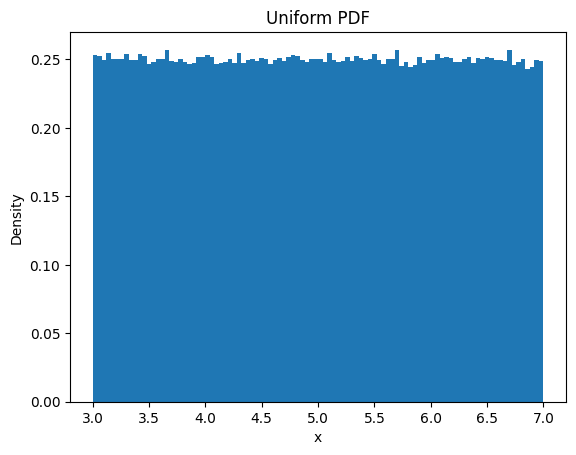

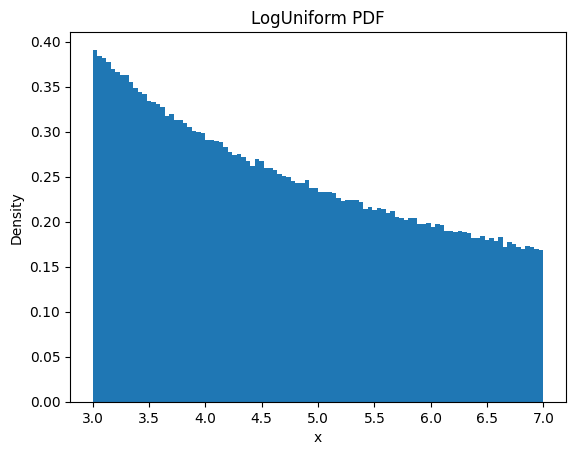

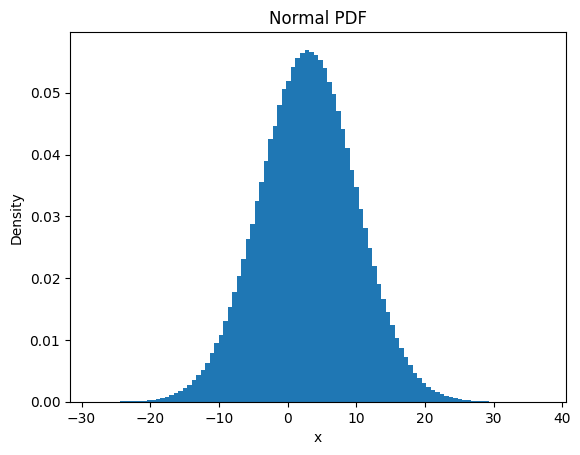

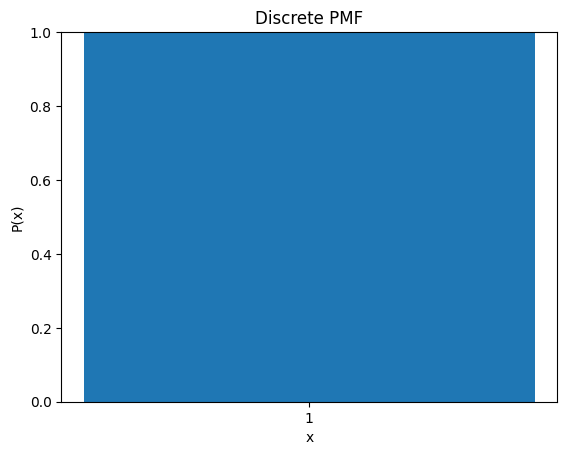

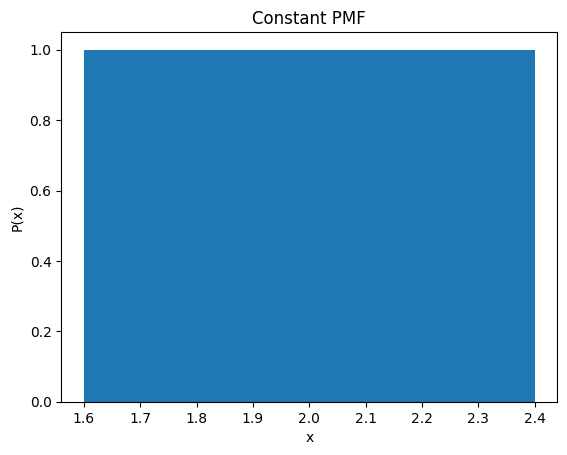

In [6]:


d = random_generators.Uniform(3,7)
d.plot_pmf()

d = random_generators.LogUniform(3,7)
d.plot_pmf()

d = random_generators.Normal(3,7)
d.plot_pmf()

x = [1]
p = [1]
d = random_generators.DiscreteChoice(x, p)
d.plot_pmf()

d = random_generators.Constant(2)
d.plot_pmf()

<Axes: title={'center': 'Discrete PMF'}, xlabel='x', ylabel='P(x)'>

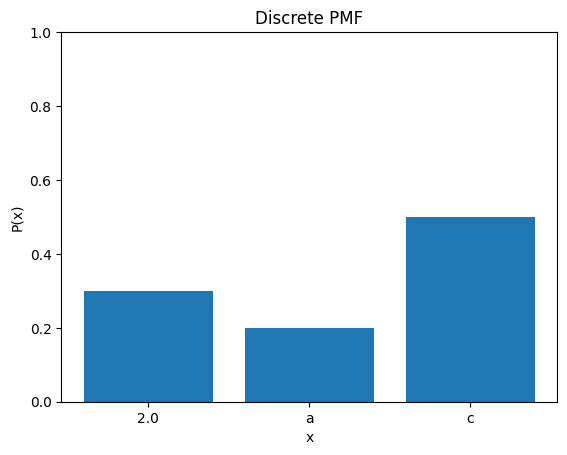

In [3]:
x = ['a', 2., 'c']
p = [0.2, 0.3, 0.5]
d = random_generators.DiscreteChoice(x, p)
d.plot_pmf()
    

<Axes: xlabel='Distance', ylabel='Depth'>

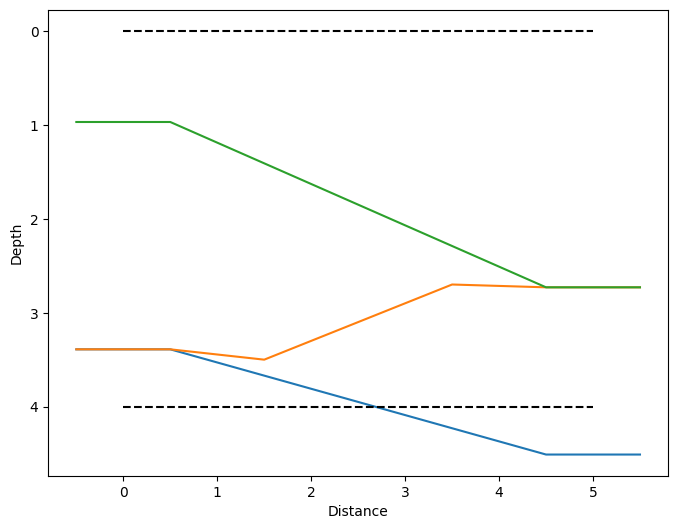

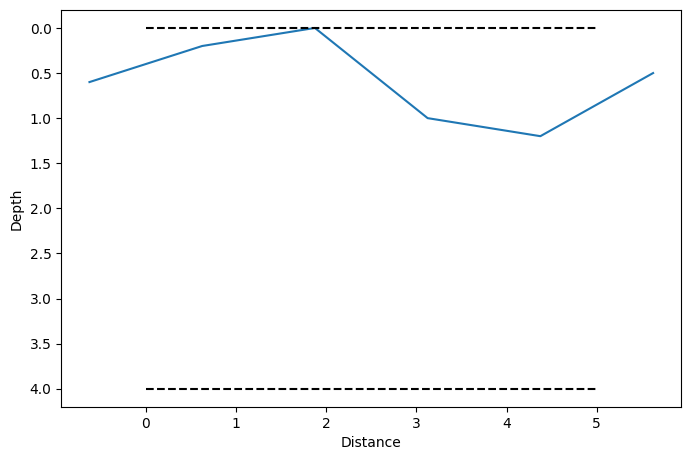

In [21]:
boundary2D.plot()
surface_boundary2D.plot()

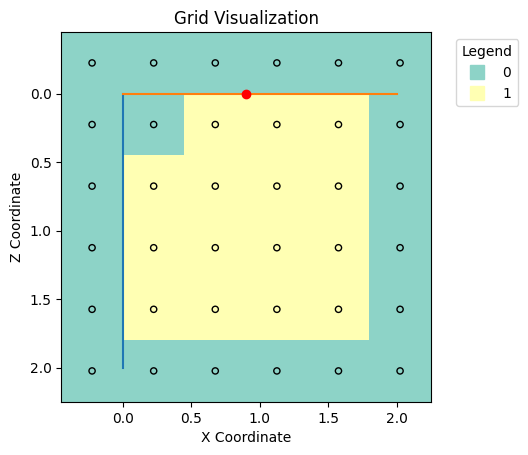

In [22]:
obs2D2 = geomodgen2d.obstruction_2d.Obstruction2D(dl=0.45, ref_xz_symbolic=('C', 0), snap_to_dl=False)  #Should be same as above
obs2D2.circular_2d(2, 1)

ax = obs2D2.plot(discrete_point_size=20, show_padding=True)
ax.plot([0,0],[2,0])
ax.plot([0,2],[0,0])

[0 1 1 1 0 0 0 0 1 1 1]


array([4.11, 6.79])

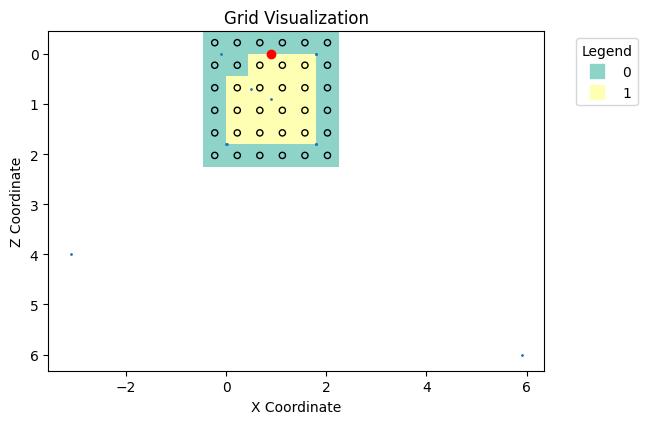

In [23]:
import matplotlib.pyplot as plt

## Test obs2d: query_points_in_obstruction
query_points = [[4.1,6.8], [4.11, 6.79], #Left Bottom Corner (0 due to nearest) and 1(inside)
                [5, 5.9], [4.6, 5.7], # Inside (1,1)
                [4, 5], [1, 9], [10, 11], #Outside (0,0,0)
                [5.89, 5], [5.89, 6.8], #Right corners (0,1 due to nearest 0.5 handling)
                [5.89, 5.01], [5.89, 6.79], #(1,1)
               ]
expected = [0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1]
print(obs2D2.query_points_in_obstruction(query_points, [5,5]))
ax = obs2D2.plot(discrete_point_size=20, show_padding=True)

plt_points = np.array(query_points) - np.asarray([5,5]) + obs2D2.get_ref_xz_in_unit_length()
ax.scatter(plt_points[:,0], plt_points[:,1],s=1)
np.array(query_points)[1]

In [24]:
import scipy
actual_point_coord = query_points
shift_ref2d_to_act = [5, 5]

grid_2d = obs2D2.grid2d
grid_2d = np.pad(grid_2d, pad_width=1, mode='constant', constant_values=0) #Note padded one so ref_coord also add 1 

center_2d = np.asarray(obs2D2.get_ref_xz_in_unit_length())
shift_ref2d_to_act = np.asarray(shift_ref2d_to_act)
actual_point_coord = np.asarray(actual_point_coord)

if shift_ref2d_to_act.shape != (2,):
    raise ValueError("shift_ref2d_to_act must have shape (2,)")

if actual_point_coord.ndim != 2 or actual_point_coord.shape[1] != 2:
    raise ValueError("actual_point_coord must have shape (N,2)")

if center_2d.shape != (2,):
    raise ValueError("center_2d must have shape (2,)")

n_x, n_z = grid_2d.shape
max_x, max_z = (n_x) * obs2D2.dl, (n_z) * obs2D2.dl

x_grid =  np.arange(n_x)*obs2D2.dl+obs2D2.dl/2 - obs2D2.dl
z_grid =  np.arange(n_z)*obs2D2.dl+obs2D2.dl/2 - obs2D2.dl

actual_point_coord = actual_point_coord - shift_ref2d_to_act + center_2d
x, z = actual_point_coord[:,0], actual_point_coord[:,1]

# Step 1: Cheap filters
keep = (0 <= x) & (x <= max_x) & (0 <= z) & (z <= max_z)

vals = np.zeros(len(actual_point_coord), dtype=int)

if not np.any(keep):
    print(vals)  # all rejected

# Step 2: Cropping indices (optional but keeps interpolation efficient)
n_extra_grids = 2
min_z_idx = max(0, int(np.floor((z[keep].min() - z_grid.min()) / obs2D2.dl)) - n_extra_grids)
max_z_idx = min(n_z-1, int(np.ceil((z[keep].max() - z_grid.min()) / obs2D2.dl)) + n_extra_grids)
min_x_idx = max(0, int(np.floor((x[keep].min() - x_grid.min()) / obs2D2.dl)) - n_extra_grids)
max_x_idx = min(n_x-1, int(np.ceil((x[keep].max() - x_grid.min()) / obs2D2.dl)) + n_extra_grids)

cropped_grid = grid_2d[min_x_idx:max_x_idx + 1, min_z_idx:max_z_idx + 1]
cropped_z = z_grid[min_z_idx:max_z_idx + 1]
cropped_x = x_grid[min_x_idx:max_x_idx + 1]

interp = scipy.interpolate.RegularGridInterpolator(
    (cropped_x, cropped_z),
    cropped_grid,
    method="nearest",
    bounds_error=False,
    fill_value=0,
)

vals[keep] = interp(np.column_stack((x[keep], z[keep]))).astype(int)
vals

array([0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1])

In [25]:
obs2D1 = geomodgen2d.obstruction_2d.Obstruction2D(dl=0.5, ref_xz_symbolic=('C', 0), snap_to_dl=False)  #Should be same as above
obs2D1.circular_2d(2, 1)

obs2D2 = geomodgen2d.obstruction_2d.Obstruction2D(dl=0.5, ref_xz_symbolic=('0', 0), snap_to_dl=False)  #Should be same as above
obs2D2.rectangle_2d(3, 2, 2)


array([['1', '2', '2', '4'],
       ['1', '2', '2', '3'],
       ['1', '1', '2', '3'],
       ['0', '1', '2', '3'],
       ['0', '1', '1', '3']], dtype='<U1')

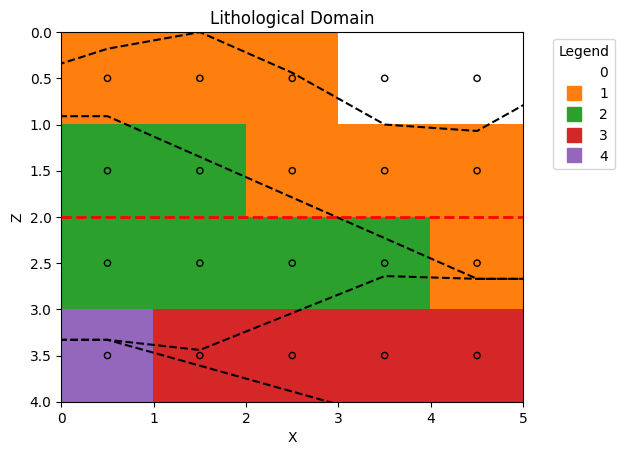

In [26]:
import geomodgen2d.lithological_domain2d as lithological_domain2d
importlib.reload(lithological_domain2d)

lithological_domain2d.GlobalSoilInterfaceConfig.set_soil_interface(boundary2D, surface_boundary2D, 'erode')

name = 'asdf'
lit = lithological_domain2d.LithologicalDomain2D(2, name)
# lit.remeshing_layered_matrix(span_x, span_z, del_x_final, del_z_final)
lit.plot2d(discrete_point_size = 20, plot_boundary=True)
# boundary.io.print()
lit.lithological_matrix

In [89]:
domain2D = geomodgen2d.discretized_domain2d.DiscretizedDomain2D(
    span_x=5, span_z=4, dx=.5, dz=.5
)

obs_lit = lithological_domain2d.LithologicalDomain2DFromObstruction2D(domain2D, 'obst')
# obs_lit.add_obstruction2D(obs2D1, [1.4,1.7], 'U')
obs_lit.add_obstruction2D(obs2D1, [2.2, 0], 'U')

<Axes: title={'center': 'Lithological Domain'}, xlabel='X', ylabel='Z'>

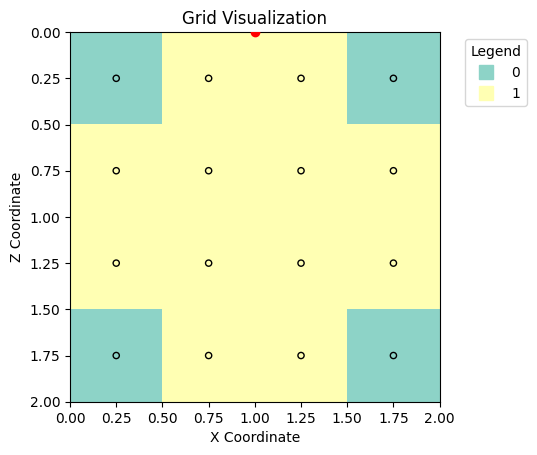

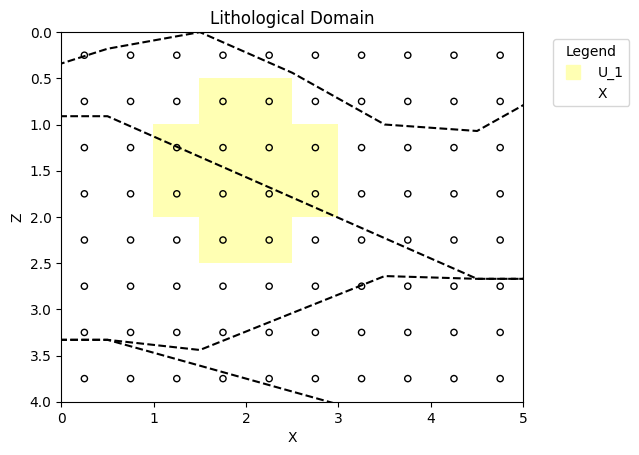

In [90]:
obs2D1.plot(discrete_point_size = 20)
obs_lit.plot2d(discrete_point_size = 20, plot_boundary=True)


In [ ]:
obs_lit.add_obstruction2D(obs2D2, [1.6,0.7], 'U')
obs_lit.plot2d(discrete_point_size = 20, plot_boundary=True)

<Axes: title={'center': 'Lithological Domain'}, xlabel='X', ylabel='Z'>

<Axes: title={'center': 'Lithological Domain'}, xlabel='X', ylabel='Z'>

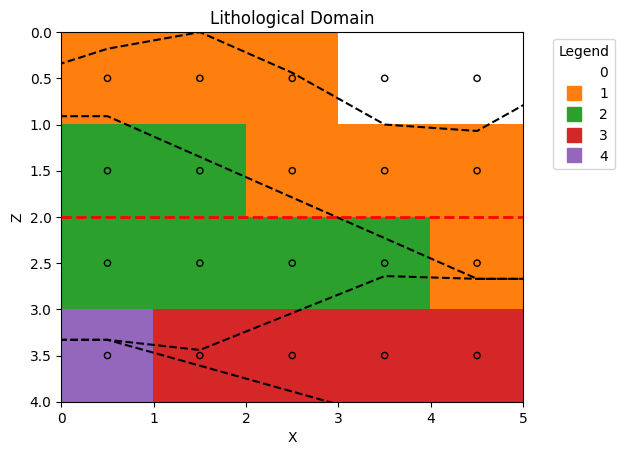

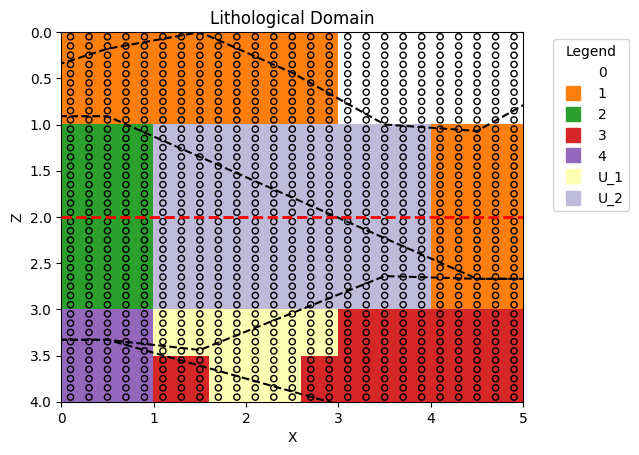

In [30]:
merged_lit = lit.return_merged_lithological_domain([obs_lit])
lit.plot2d(discrete_point_size = 20, plot_boundary=True)
merged_lit.plot2d(discrete_point_size = 20, plot_boundary=True)

<Axes: title={'center': 'Lithological Domain'}, xlabel='X', ylabel='Z'>

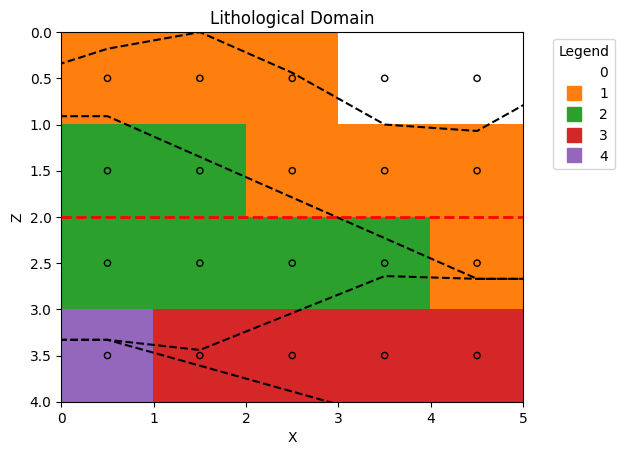

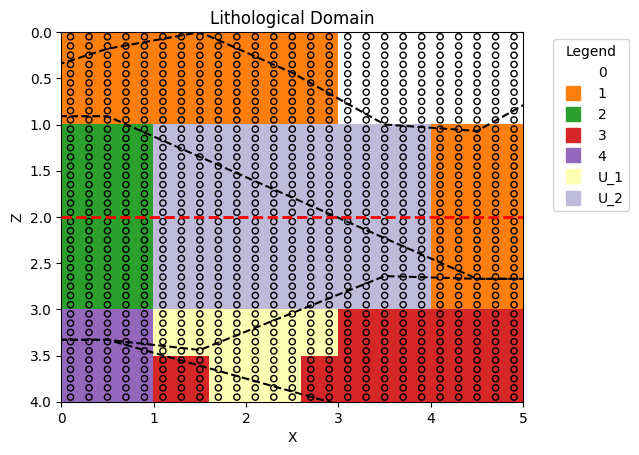

In [31]:
lit = lithological_domain2d.LithologicalDomain2D(2, name)

obs_lit = lithological_domain2d.LithologicalDomain2DFromObstruction2D(domain2D, 'obst')
obs_lit.add_obstruction2D(obs2D1, [2,2], 'U')

obs_lit2 = lithological_domain2d.LithologicalDomain2DFromObstruction2D(domain2D, 'obst')
obs_lit2.add_obstruction2D(obs2D2, [1,1], 'U')

merged_lit = lit.return_merged_lithological_domain([obs_lit, obs_lit2])
lit.plot2d(discrete_point_size = 20, plot_boundary=True)
merged_lit.plot2d(discrete_point_size = 20, plot_boundary=True)

Circular 2d of radius 0.2, then rotated by angle (in degrees) of 80 about z-axis + Circular 2d of radius 0.4, then rotated by angle (in degrees) of 80 about z-axis + Circular 2d of radius 1.5, then rotated by angle (in degrees) of 80 about z-axis + Rectangular 2d of size (lz x lx) = (0.2 x 0.5), then rotated by angle (in degrees) of 80 about z-axis


True

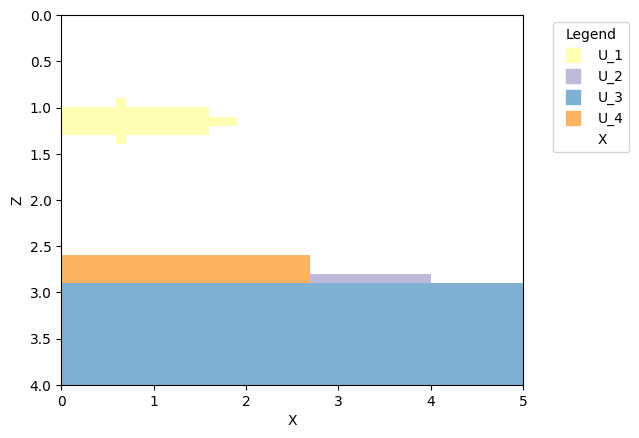

In [15]:
if len(util_lit_list)!=0:
    merged_util_lit = lithological_domain2d.LithologicalDomain2D_from_Utils2D(span_x, span_z, del_x_final, del_z_final, 'util_merged', surfaceBoundaryCreator_class=surf)
    for util_lit in util_lit_list:
        merged_util_lit.merge_with_another_lithological_domain(util_lit)
    # lit.merge_with_another_lithological_domain(merged_util_lit)
merged_util_lit.plot2d()
print(merged_util_lit.utils_description)
merged_util_lit.overlap

<Axes: xlabel='X', ylabel='Z'>

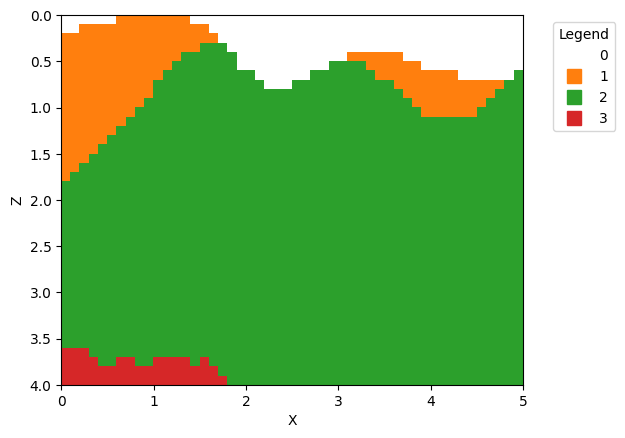

In [16]:
lit.plot2d()

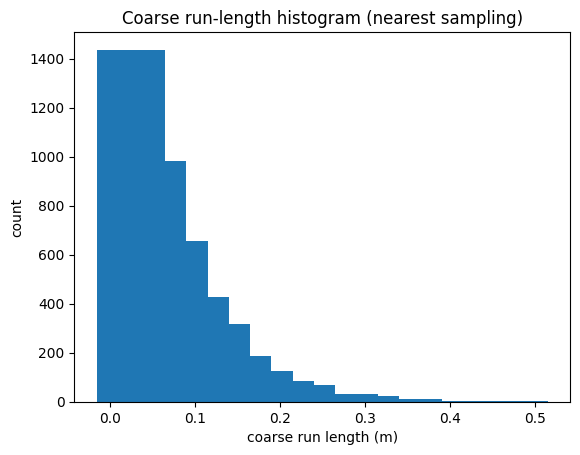

1 coarse cells → 0.03 m : count 1436
2 coarse cells → 0.05 m : count 984
3 coarse cells → 0.08 m : count 654
4 coarse cells → 0.10 m : count 427
5 coarse cells → 0.12 m : count 318
6 coarse cells → 0.15 m : count 187
7 coarse cells → 0.18 m : count 124
8 coarse cells → 0.20 m : count 83


In [4]:
import numpy as np
from collections import Counter
import matplotlib.pyplot as plt

np.random.seed(0)

# params
fine_dx = 0.025
coarse_dx = 0.025
block = int(coarse_dx / fine_dx)  # =4

# build a long single utility: for each along-track column choose a thickness L ~ U(1,6)
Ncols = 20000               # along-track length (fine cells)
height = 40                 # vertical size in fine cells (big enough)
# create empty grid
grid = np.zeros((height, Ncols), dtype=np.int8)

# vertical anchor: put utility somewhere in middle vertically
base = 10  # top index of utility (so utility occupies rows base .. base+L-1)
for j in range(Ncols):
    L = np.random.randint(1,7)           # thickness in fine cells (1..6)
    grid[base:base+L, j] = 1             # single utility labeled '1'

# simulate RegularGridInterpolator(nearest) sampling: sample one fine cell per block
# choose offset 0..block-1 that RGI would pick (depends on alignment). Try offset=1 as example
offset = 10
sampled_cols = np.arange(offset, Ncols, block)  # indices of sampled fine columns
# for each sampled column we need only whether sampled point is inside utility:
# pick the sampled fine-row index that corresponds to the coarse center vertically.
# For simplicity we sample the same vertical row that corresponds to utility mid-height:
sample_row = base + 2  # pick a representative vertical sample row (nearest)
sampled = grid[sample_row, sampled_cols]  # 1 if utility present at that sampled point

# compute run-lengths (consecutive 1s) in sampled sequence
runs = []
cur = sampled[0]; cnt = 1
for v in sampled[1:]:
    if v == cur:
        cnt += 1
    else:
        if cur == 1:
            runs.append(cnt)
        cur = v; cnt = 1
# final
if cur == 1:
    runs.append(cnt)
runs = np.array(runs)

# histogram of coarse-run lengths in meters
counts = Counter(runs)
xs = np.array(sorted(counts.keys())) * coarse_dx
ys = np.array([counts[k] for k in sorted(counts.keys())])

plt.bar(xs, ys, width=0.08)
plt.xlabel('coarse run length (m)')
plt.ylabel('count')
plt.title('Coarse run-length histogram (nearest sampling)')
plt.show()

# print top peaks
for k,c in sorted(counts.items(), key=lambda x:-x[1])[:8]:
    print(f"{k} coarse cells → {k*coarse_dx:.2f} m : count {c}")


In [5]:
 np.full((5,6), 1)

array([[1, 1, 1, 1, 1, 1],
       [1, 1, 1, 1, 1, 1],
       [1, 1, 1, 1, 1, 1],
       [1, 1, 1, 1, 1, 1],
       [1, 1, 1, 1, 1, 1]])

In [9]:
import geomodgen2d.random_generators as random_generators
import numpy as np
x = ['a', 2., 'c']
p = [0.2, 0.3, 0.5]
d = random_generators.DiscreteChoice(x, p)
print(d.x, d.p)

result = d.generate(size=(1000,))
print(set(result).issubset(set(np.array(x))))
print(set(result))

# Check if probabilities roughly match
counts = [np.sum(result == xi)/len(result) for xi in np.array(x)]

print(counts, p)
# for c, expected in zip(counts, p):
#     self.assertAlmostEqual(c, expected, delta=0.02)
    

['a' '2.0' 'c'] [0.2 0.3 0.5]
True
{np.str_('c'), np.str_('a'), np.str_('2.0')}
[np.float64(0.197), np.float64(0.284), np.float64(0.519)] [0.2, 0.3, 0.5]


In [ ]:
np.round(2/2.4)